# Global Dataset Exploratory Data Analysis (EDA)

## Objective
- Memahami pola data global
- Mengidentifikasi tren skill dan role
- Membandingkan dengan dataset local

# **Sel 1: Load Dataset**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data hasil preprocessing tadi
df_global = pd.read_csv('../data/global_jobs_cleaned.csv')

# Cek data
print(f"Dataset Shape: {df_global.shape}")
df_global.head(100)

Dataset Shape: (718, 7)


,title,company_name,skills,location_city,skills_cleaned,skills_count,role
0,.NET Developer,Global Company,C#; VB.NET basics; .NET Framework; .NET Core f...,Remote/International,"c#, vb.net basics, .net framework, .net core f...",15,Other Tech
1,.NET Developer,Global Company,C#; .NET Framework basics; ASP.NET; Razor; HTM...,Remote/International,"c#, .net framework basics, asp.net, razor, htm...",10,Other Tech
2,.NET Developer,Global Company,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTM...,Remote/International,"c#, vb.net basics, .net core, asp.net mvc, htm...",9,Other Tech
3,.NET Developer,Global Company,C#; .NET Framework; ASP.NET basics; SQL Server...,Remote/International,"c#, .net framework, asp.net basics, sql server...",8,Other Tech
4,.NET Developer,Global Company,C#; ASP.NET; MVC; Entity Framework basics; SQL...,Remote/International,"c#, asp.net, mvc, entity framework basics, sql...",8,Other Tech
...,...,...,...,...,...,...,...
95,Backend Developer - Entry Level,Global Company,Node.js; Python; Java; Express.js; Flask; Djan...,Remote/International,"node.js, python, java, express.js, flask, djan...",13,Software Engineering
96,Backend Developer - Entry Level,Global Company,Node.js; Python; Java; Express.js; Flask; Djan...,Remote/International,"node.js, python, java, express.js, flask, djan...",13,Software Engineering
97,Backend Developer - Entry Level,Global Company,Node.js; Python; Express.js; Flask; Django; My...,Remote/International,"node.js, python, express.js, flask, django, my...",12,Software Engineering
98,Backend Developer - Entry Level,Global Company,Node.js; Python; Express.js; Flask; Django; My...,Remote/International,"node.js, python, express.js, flask, django, my...",13,Software Engineering


# **Overview Dataset**

In [2]:
# Tampilkan info dasar dataset
print("--- Overview Dataset Global ---")
print(f"Total Jumlah Baris: {len(df_global)}")
print(f"Total Jumlah Kolom: {len(df_global.columns)}")

# Cek tipe data dan missing values lagi untuk memastikan
print("\nInfo Struktur Data:")
df_global.info()

# Tampilkan deskripsi statistik untuk kolom numerik (seperti skills_count)
print("\nStatistik Deskriptif (Skills Count):")
print(df_global['skills_count'].describe())

--- Overview Dataset Global ---
Total Jumlah Baris: 718
Total Jumlah Kolom: 7

Info Struktur Data:
<class 'pandas.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   title           718 non-null    str  
 1   company_name    718 non-null    str  
 2   skills          718 non-null    str  
 3   location_city   718 non-null    str  
 4   skills_cleaned  718 non-null    str  
 5   skills_count    718 non-null    int64
 6   role            718 non-null    str  
dtypes: int64(1), str(6)
memory usage: 331.8 KB

Statistik Deskriptif (Skills Count):
count    718.000000
mean      13.162953
std        5.758014
min        4.000000
25%        9.000000
50%       13.000000
75%       17.000000
max       35.000000
Name: skills_count, dtype: float64


# **Distribusi Role**

/var/folders/8t/xt3dqm391b19xqdv7kq_yxw80000gn/T/ipykernel_23451/2763864994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_counts.values, y=role_counts.index, palette='viridis')


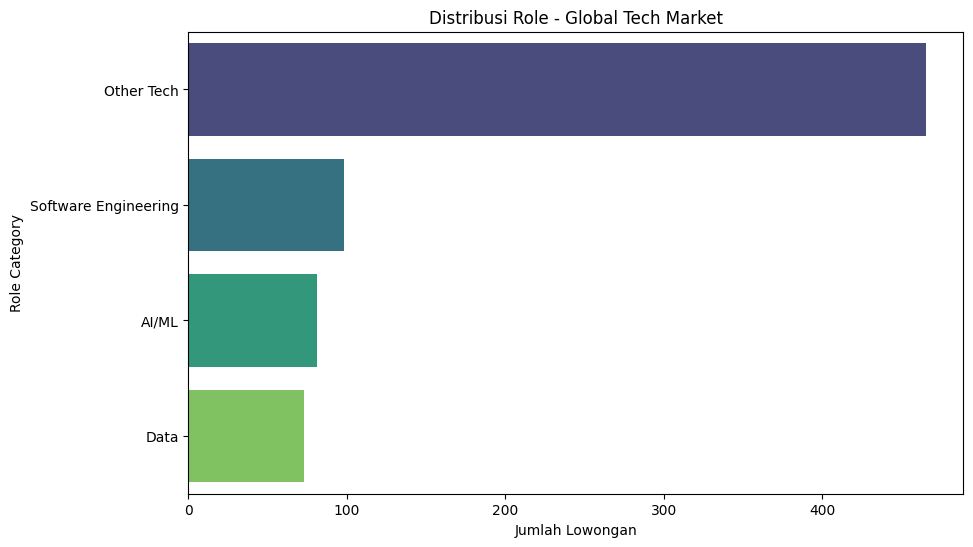

Role paling dominan secara global adalah: Other Tech


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Hitung jumlah tiap role
role_counts = df_global['role'].value_counts()

# Visualisasi (bar chart)
sns.barplot(x=role_counts.values, y=role_counts.index, palette='viridis')

plt.title('Distribusi Role - Global Tech Market')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Role Category')
plt.show()

print(f"Role paling dominan secara global adalah: {role_counts.idxmax()}")

# **Distribusi Skill (Top 10)**

/var/folders/8t/xt3dqm391b19xqdv7kq_yxw80000gn/T/ipykernel_23451/2439651714.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_skills.values, y=top_10_skills.index, palette='magma')


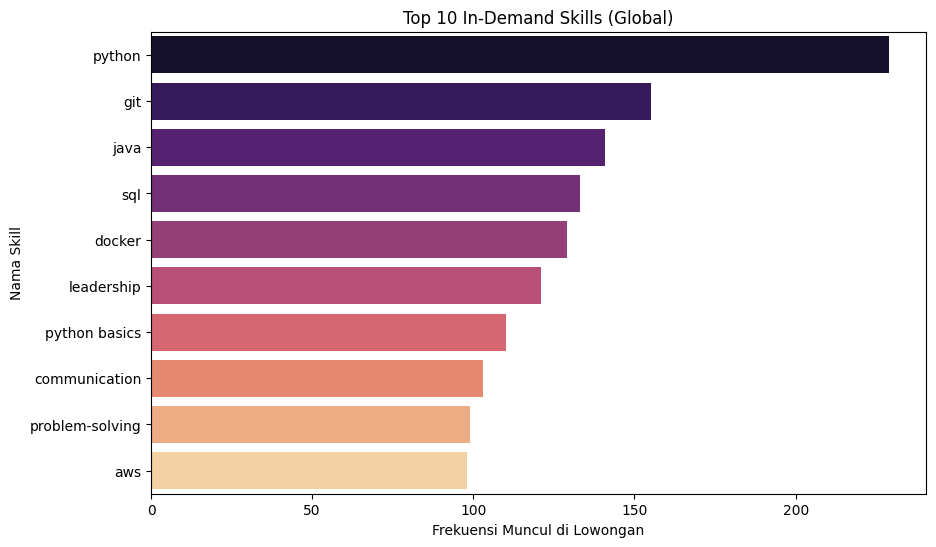

In [4]:
# Ekstrak semua skill dari kolom skills_cleaned
all_skills = df_global['skills_cleaned'].str.split(',').explode()
all_skills = all_skills.str.strip()

# Hitung frekuensi skill
top_10_skills = all_skills.value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_skills.values, y=top_10_skills.index, palette='magma')

plt.title('Top 10 In-Demand Skills (Global)')
plt.xlabel('Frekuensi Muncul di Lowongan')
plt.ylabel('Nama Skill')
plt.show()

# **Skills Count Analysis**

Rata-rata jumlah skill per lowongan global: 13.16


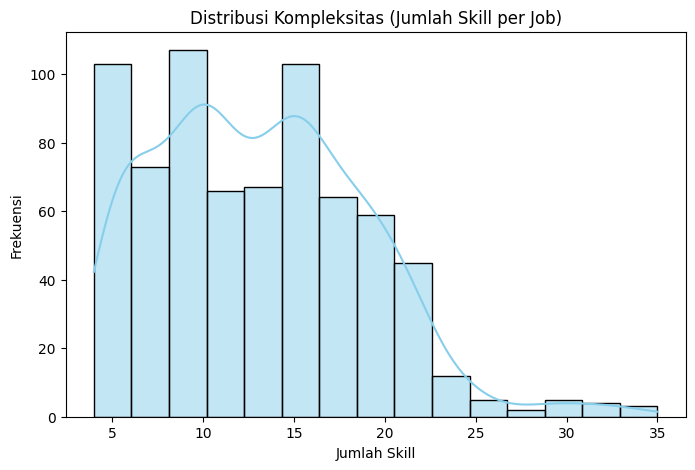

In [5]:
# Rata-rata jumlah skill (skills_count)
avg_skills = df_global['skills_count'].mean()
print(f"Rata-rata jumlah skill per lowongan global: {avg_skills:.2f}")

# Visualisasi distribusi skill count
plt.figure(figsize=(8, 5))
sns.histplot(df_global['skills_count'], kde=True, color='skyblue', bins=15)
plt.title('Distribusi Kompleksitas (Jumlah Skill per Job)')
plt.xlabel('Jumlah Skill')
plt.ylabel('Frekuensi')
plt.show()

# **Location Analysis**

Distribusi Lokasi Global:
location_city
Remote/International    718
Name: count, dtype: int64


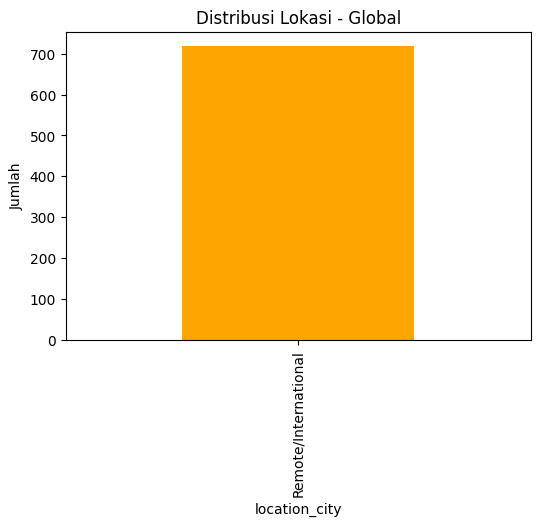

In [6]:
# Cek distribusi lokasi
location_counts = df_global['location_city'].value_counts()
print("Distribusi Lokasi Global:")
print(location_counts)

# Visualisasi sederhana
plt.figure(figsize=(6, 4))
location_counts.plot(kind='bar', color='orange')
plt.title('Distribusi Lokasi - Global')
plt.ylabel('Jumlah')
plt.show()

# **Sel 7: Insight Summary (Global)**


Dominasi Skill: Python adalah skill yang paling krusial dengan frekuensi kemunculan tertinggi (di atas 200), disusul oleh Git dan Java.  

Kebutuhan DevOps: Munculnya Docker dan AWS dalam Top 10 menunjukkan bahwa pasar global sangat memprioritaskan kemampuan pengelolaan infrastruktur cloud.  

Soft Skills: Menariknya, leadership dan communication masuk dalam daftar utama, yang berarti perusahaan global tidak hanya mencari kemampuan teknis.

# **Comparison: Global vs Local**

In [7]:
try:
    # Memanggil file lokal yang sudah dibersihkan
    df_local = pd.read_csv('data/magangin_jobs_cleaned.csv')
    avg_skills_local = df_local['skills_count'].mean()

    print("--- HASIL PERBANDINGAN FINAL ---")
    print(f"Rata-rata Skill Global : {avg_skills_global:.2f}")
    print(f"Rata-rata Skill Lokal  : {avg_skills_local:.2f}")

    # Menghitung selisih
    diff = avg_skills_global - avg_skills_local
    print(f"\nSelisih kompleksitas: {diff:.2f} skill")

except FileNotFoundError:
    print("File 'magangin_jobs_cleaned.csv' tidak ditemukan di folder Colab.")
    print("Pastikan kamu sudah mengunggah file tersebut ke menu 'Files' di sebelah kiri.")

File 'magangin_jobs_cleaned.csv' tidak ditemukan di folder Colab.
Pastikan kamu sudah mengunggah file tersebut ke menu 'Files' di sebelah kiri.


# **Key Insights**

Kesenjangan Standar Kompetensi: Terdapat perbedaan yang sangat signifikan antara rata-rata skill Global (13.16) dan Lokal (5.23). Hal ini menunjukkan bahwa industri global mengharapkan kandidat yang memiliki pemahaman teknologi yang jauh lebih luas dan mendalam.

Ekspektasi Multi-Disiplin: Dengan rata-rata di atas 13 skill, lowongan global kemungkinan besar menggabungkan peran teknis dengan kemampuan DevOps (seperti AWS dan Docker yang muncul di grafik sebelumnya) serta soft skills.
  
Peluang Pengembangan: Selisih hampir 8 skill ini menjadi tantangan sekaligus peluang bagi proyek Magang-In untuk menjembatani kesenjangan kompetensi mahasiswa agar siap bersaing di kancah internasional.

# **Conclusion**

**"Analisis perbandingan ini menunjukkan adanya kesenjangan kompetensi yang cukup lebar antara pasar kerja global dan lokal, dengan selisih mencapai 7.93 skill per lowongan. Kesimpulan ini sangat krusial bagi pengembangan proyek Magang-In, di mana sistem rekomendasi kami nantinya tidak hanya harus menyesuaikan dengan kebutuhan pasar lokal, tetapi juga memberikan arahan strategis bagi pengguna untuk mengejar standar global yang lebih kompleks. Dengan selesainya tahap EDA ini, data siap digunakan untuk pengembangan modul selanjutnya."**